Monthly Average Temperature:
   year  month   avg_temp
0  2022      1  21.178571

Hottest Day: 2022-01-01 with an average temperature of 38.0°F
Coldest Day: 2022-01-14 with an average temperature of 9.5°F


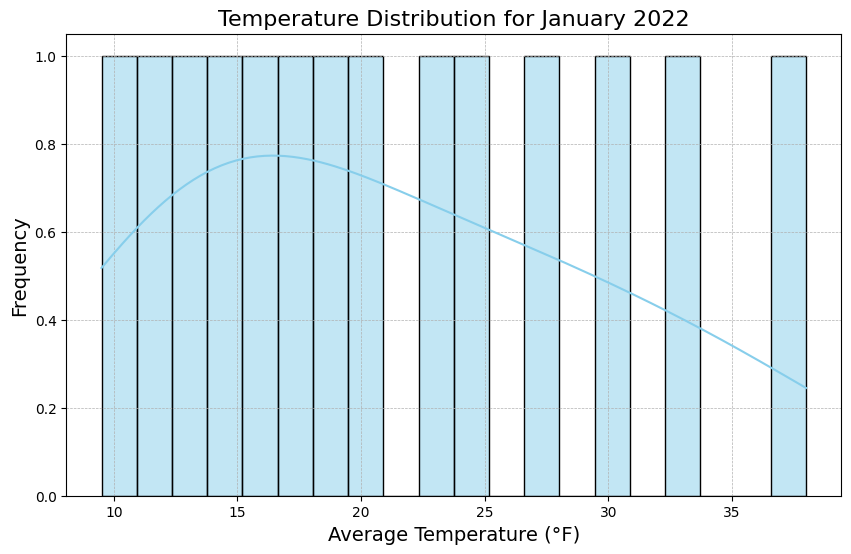

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Note: Ensure the path is correct for your local environment
file_path = pd.read_csv('weather_data.csv')
weather_data = pd.read_csv('weather_data.csv')

# Changed format from '%d/%m/%Y' to '%m/%d/%Y' because your data is Month/Day/Year
weather_data["date"] = pd.to_datetime(weather_data["date"], format='%m/%d/%Y')
# ---------------

# Extracting month and year from the date
weather_data["month"] = weather_data["date"].dt.month
weather_data["year"] = weather_data["date"].dt.year

# Calculating the average temperature for each day
# Formula: $T_{avg} = \frac{T_{min} + T_{max}}{2}$
weather_data["avg_temp"] = (weather_data["min_temp"] + weather_data["max_temp"]) / 2

# Calculating the monthly average temperature
monthly_avg_temp = weather_data.groupby(["year", "month"])["avg_temp"].mean().reset_index()

# Finding the hottest and coldest days
hottest_day = weather_data.loc[weather_data["avg_temp"].idxmax()]
coldest_day = weather_data.loc[weather_data["avg_temp"].idxmin()]

# Displaying the results
print("Monthly Average Temperature:")
print(monthly_avg_temp)
print(f"\nHottest Day: {hottest_day['date'].strftime('%Y-%m-%d')} with an average temperature of {hottest_day['avg_temp']:.1f}°F")
print(f"Coldest Day: {coldest_day['date'].strftime('%Y-%m-%d')} with an average temperature of {coldest_day['avg_temp']:.1f}°F")

# Plotting the histogram for temperature distribution
plt.figure(figsize=(10, 6))
sns.histplot(weather_data["avg_temp"], bins=20, kde=True, color="skyblue", edgecolor="black")

plt.xlabel("Average Temperature (°F)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Temperature Distribution for January 2022", fontsize=16)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()
